## Section A

### 1. Identify the string methods and their execution order needed to remove extra spaces and fix inconsistent casing in a product name. 

To clean a product name, two Python string methods are commonly used:

strip(): Removes extra spaces from the beginning and end of the string.
title(): Converts the first letter of each word to uppercase and the remaining letters to lowercase.

Execution Order:

Apply strip() to remove unnecessary spaces.
Apply title() to standardize the text formatting.

This order ensures that the product name is clean and consistently formatted.

### 2. Explain why manual CSV loading often treats numeric columns as strings and identify the function used to convert them to floats.

CSV (Comma-Separated Values) files store all data as plain text. When a CSV file is loaded manually, Python initially reads every value as a string because it cannot automatically determine the correct data type.

Numeric columns may also contain symbols such as currency signs ($, ₹) or commas, which prevent them from being recognized as numbers.

To convert a string containing a numeric value into a floating-point number, the float() function is used after cleaning the data.

### 3. Determine the best data structure for mapping product names to total sales and explain the drawback of using a list instead.

A dictionary is the most suitable data structure for mapping product names to their total sales because it stores data as key-value pairs, where the product name acts as the key and the total sales act as the value.

Using a dictionary allows:

Fast searching using the product name.
Easy updating of sales values.
Efficient storage of related information.

A list is not suitable because it stores values by position rather than by name. Finding or updating the sales of a specific product requires searching through the entire list, making it slower and less efficient.

### 4. Compare using a manual for loop versus the sum() function, identifying a scenario where the loop is the only viable option.

The sum() function is used to quickly calculate the total of numeric values in a collection. It is simple, efficient, and requires very little code.

A manual for loop is more flexible because it allows additional operations to be performed on each value before it is added.

A for loop is the only practical option when:

Data needs to be cleaned before summing.
Invalid values need to be skipped.
Conditions or calculations must be applied to each item.
Data conversion is required before addition.

Therefore, while sum() is useful for clean numeric data, a for loop is necessary when preprocessing or validation is involved.

### 5. Describe how to implement type checking or error handling to prevent a TypeError when comparing a potential string variable to a number.

A TypeError occurs when Python attempts to compare values of incompatible data types, such as a string and an integer.

This can be prevented in two ways:

Type Checking: Before performing the comparison, verify that the variable is of a numeric type using functions such as isinstance().
Error Handling: Use a try-except block to safely convert the value into a numeric type. If the conversion fails, the program can handle the error without crashing.

These approaches make the program more reliable and prevent unexpected runtime errors.

### 6. Explain the benefits of modularizing a data pipeline into separate functions and the risks of using a single large code block in analytics.

Modularizing a data pipeline means dividing the program into smaller functions, where each function performs a specific task.

Benefits of Modularization
Improves code readability.
Makes debugging easier.
Encourages code reuse.
Simplifies maintenance and updates.
Makes collaboration easier in team projects.
Improves scalability as the project grows.
Risks of Using a Single Large Code Block
Difficult to understand and maintain.
Errors are harder to locate and fix.
Code duplication becomes more common.
Reusing parts of the code is difficult.
Updating one section may unintentionally affect other parts of the program.

For these reasons, modular programming is considered a best practice in data analytics and software development.

## Section B

In [3]:
import pandas as pd

### 1. Load the sales_data_sample.csv file and use Python string methods to trim whitespace and apply title casing to the 'PRODUCTLINE' column. 

In [14]:
df = pd.read_csv("sales_data_sample.csv", encoding="cp1252")

In [5]:
df

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,12/2/2004 0:00,Shipped,4,12,2004,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Small
2819,10373,29,100.00,1,3978.51,1/31/2005 0:00,Shipped,1,1,2005,...,Torikatu 38,NaN,Oulu,NaN,90110,Finland,EMEA,Koskitalo,Pirkko,Medium
2820,10386,43,100.00,4,5417.57,3/1/2005 0:00,Resolved,1,3,2005,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Medium
2821,10397,34,62.24,1,2116.16,3/28/2005 0:00,Shipped,1,3,2005,...,1 rue Alsace-Lorraine,NaN,Toulouse,NaN,31000,France,EMEA,Roulet,Annette,Small


In [6]:
df["PRODUCTLINE"] = df["PRODUCTLINE"].str.strip().str.title()

In [15]:
print("Cleaned PRODUCTLINE Column:")
print(df["PRODUCTLINE"].head())

Cleaned PRODUCTLINE Column:
0    Motorcycles
1    Motorcycles
2    Motorcycles
3    Motorcycles
4    Motorcycles
Name: PRODUCTLINE, dtype: object


### 2. Iterate through the 'SALES' column to remove non-numeric characters and cast the cleaned values into a float data type. 

In [16]:
clean_sales = []

for value in df["SALES"]:
    value = str(value)
    cleaned = ""

    for ch in value:
        if ch.isdigit() or ch == ".":
            cleaned += ch

    if cleaned != "":
        clean_sales.append(float(cleaned))
    else:
        clean_sales.append(0.0)

df["SALES"] = clean_sales

print("Cleaned SALES Column:")
print(df["SALES"].head())

Cleaned SALES Column:
0    2871.00
1    2765.90
2    3884.34
3    3746.70
4    5205.27
Name: SALES, dtype: float64


### 3. Construct a dictionary where each key is a unique 'PRODUCTLINE' and the value is the cumulative sum of 'SALES' for that category.

In [17]:
sales_dict = {}

for index, row in df.iterrows():
    product = row["PRODUCTLINE"]
    sales = row["SALES"]

    if product in sales_dict:
        sales_dict[product] += sales
    else:
        sales_dict[product] = sales

print("Total Sales by Product Line:")
print(sales_dict)

Total Sales by Product Line:
{'Motorcycles': 1166388.3400000003, 'Classic Cars': 3919615.659999997, 'Trucks and Buses': 1127789.8399999996, 'Vintage Cars': 1903150.8399999992, 'Planes': 975003.5700000001, 'Ships': 714437.13, 'Trains': 226243.46999999997}


### 4. Use a loop and conditional logic to categorize product lines as "High Revenue Product" if total sales exceed 100,000, printing the results to the console.

In [18]:
print("Revenue Classification:\n")

for product, total in sales_dict.items():
    if total > 100000:
        print(f"{product}: {total:.2f} --> High Revenue Product")
    else:
        print(f"{product}: {total:.2f} --> Normal Revenue Product")

Revenue Classification:

Motorcycles: 1166388.34 --> High Revenue Product
Classic Cars: 3919615.66 --> High Revenue Product
Trucks and Buses: 1127789.84 --> High Revenue Product
Vintage Cars: 1903150.84 --> High Revenue Product
Planes: 975003.57 --> High Revenue Product
Ships: 714437.13 --> High Revenue Product
Trains: 226243.47 --> High Revenue Product


## Section C

### 1. Title: Automated Sales Integrity & Reporting Engine

### 2. Problem Statement: Transform a fragmented regional retail export into a validated, high-integrity dataset by automating the identification of data type mismatches and revenue outliers

### 3. Problem Statement: Transform a fragmented regional retail export into a validated, high-integrity dataset by automating the identification of data type mismatches and revenue outliers

### 4. Required Deliverables: Python .ipynb script, automated console summary report, documented cleaning logic overview

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("sales_data_sample.csv", encoding='latin1')

In [21]:
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [24]:
df.shape

(2823, 25)

In [25]:
df.columns

Index(['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER',
       'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID',
       'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE',
       'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE',
       'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME',
       'DEALSIZE'],
      dtype='object')

In [28]:
df.dtypes

ORDERNUMBER           int64
QUANTITYORDERED       int64
PRICEEACH           float64
ORDERLINENUMBER       int64
SALES               float64
ORDERDATE            object
STATUS               object
QTR_ID                int64
MONTH_ID              int64
YEAR_ID               int64
PRODUCTLINE          object
MSRP                  int64
PRODUCTCODE          object
CUSTOMERNAME         object
PHONE                object
ADDRESSLINE1         object
ADDRESSLINE2         object
CITY                 object
STATE                object
POSTALCODE           object
COUNTRY              object
TERRITORY            object
CONTACTLASTNAME      object
CONTACTFIRSTNAME     object
DEALSIZE             object
dtype: object

In [29]:
df.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


In [30]:
df.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
df["ORDERDATE"] = pd.to_datetime(df["ORDERDATE"])

In [35]:
df["CalculatedSales"] = (
    df["QUANTITYORDERED"] *
    df["PRICEEACH"]
)

In [36]:
df["Difference"] = (
    df["CalculatedSales"] -
    df["SALES"]
)

In [37]:
df["RevenueError"] = (
    abs(df["Difference"]) > 1
)

In [38]:
df[df["QUANTITYORDERED"] < 0]

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,CalculatedSales,Difference,RevenueError


In [ ]:
df[
df["ORDERDATE"] >
pd.Timestamp.today()
]

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,CalculatedSales,Difference,RevenueError


In [42]:
Q1 = df["SALES"].quantile(0.25)

In [ ]:
Q3 = df["SALES"].quantile(0.75)

In [44]:
IQR = Q3 - Q1

In [ ]:
lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

In [46]:
outliers = df[
(df["SALES"] < lower) |
(df["SALES"] > upper)
]

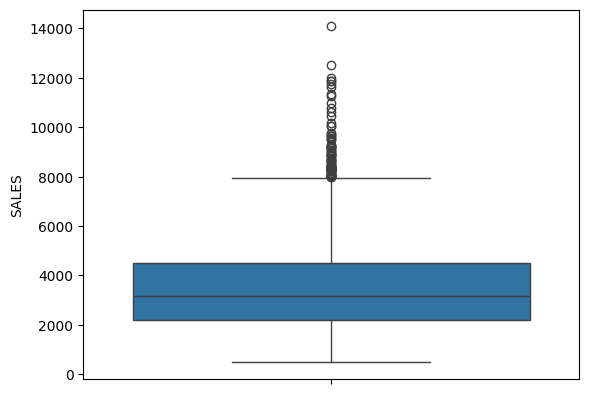

In [ ]:
sns.boxplot(df["SALES"])
plt.show()

<Axes: xlabel='SALES', ylabel='Count'>

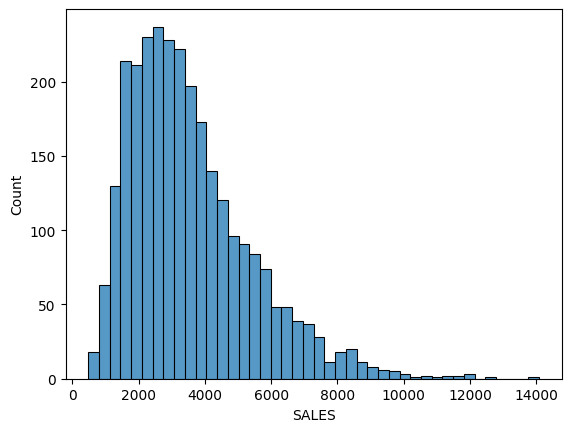

In [ ]:
sns.histplot(df["SALES"])

<Axes: xlabel='PRODUCTLINE', ylabel='SALES'>

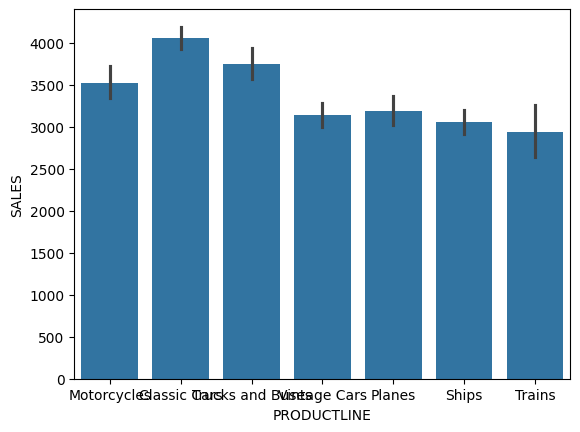

In [50]:
sns.barplot(
x="PRODUCTLINE",
y="SALES",
data=df
)

<Axes: xlabel='ORDERDATE'>

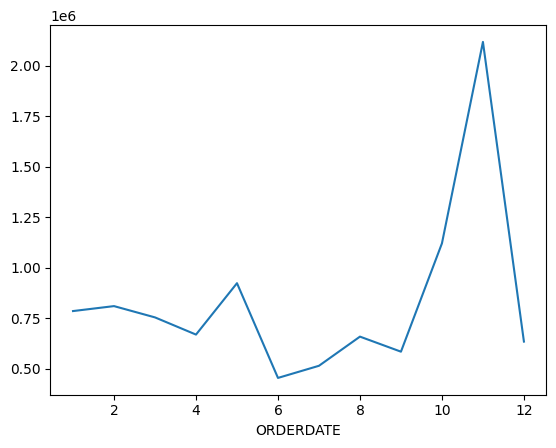

In [51]:
df.groupby(
df["ORDERDATE"].dt.month
)["SALES"].sum().plot()